In [2]:
import pandas as pd
import numpy as np 
import os
from pathlib import Path
import seaborn as sns

# Plotting
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import PolyCollection
import matplotlib.patches as mpatches
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
import matplotlib.image as mpimg

## Prepare the data for plotting

### 1) Select same combination of algorithms and model runs for no tipping scenario to make scenarios comparable

In [3]:
### Local paths

working_dir = Path.cwd().resolve()
repository_root = next(
    parent
    for parent in (working_dir, *working_dir.parents)
    if (parent / "07_postprocess_data" / "local" / "sdm_area_change" / "final_amazon_area_ETresid_updated.csv").is_file()
)

# Large all-species SDM area-change table supplied in the local reproducibility-data folder
area_csv = pd.read_csv(
    repository_root
    / "07_postprocess_data"
    / "local"
    / "sdm_area_change"
    / "final_amazon_area_ETresid_updated.csv"
)

# Small species metadata table bundled with step 04
full_species_list_amazonas = pd.read_csv(
    repository_root
    / "04_rasterize_species"
    / "local"
    / "data"
    / "full_species_list_amazon_updated.csv"
)

# Local Figure 3 output folder
save_dir = repository_root / "08_figures" / "main_figures" / "figure_3" / "output"
save_dir.mkdir(parents=True, exist_ok=True)


In [6]:
### Select scenario

# SSP
ssp = "ssp245"

# Dispersal scenario 
dispersal_scenario = "full_dispersal"

In [4]:
# Prepare data
sample_structure = (
    area_csv[area_csv["tip"] == "tip"]
    [["algo", "model_run", "prec_sample"]]
    .drop_duplicates()
)

# Select no tipping data
notip = area_csv[area_csv["tip"] == "notip"].copy()

# Inner merge to add prec samples to no tipping scenario
expanded_notip = notip.merge(
    sample_structure,
    on=["algo", "model_run"],
    how="inner"   
)

# Combine
area_csv = pd.concat([
    expanded_notip,
    area_csv[area_csv["tip"] == "tip"]
], ignore_index=True)

# Clean 
area_csv["prec_sample"] = area_csv["prec_sample"].fillna(area_csv["prec_sample_y"])
area_csv = area_csv.drop(columns=['prec_sample_x',"prec_sample_y"])

### 2) Calculate median of relative change in area in amazon basin across all species

In [7]:
median_df = (area_csv.groupby(
    ['ssp', 'tip', 'deforestation', 'time_period', "algo", "model_run", 'prec_sample'], dropna=False)
    [f'relative_change_amazon_area_{dispersal_scenario}'] 
    .median()
    .reset_index()
)

# Summarize CI statistics
summary = (
    median_df
    .groupby(['ssp', 'tip', 'deforestation', 'time_period'])
    [f'relative_change_amazon_area_{dispersal_scenario}']
    .agg([
        ('median', 'median'),
        ('lower', lambda x: np.quantile(x, 0.025)),
        ('upper', lambda x: np.quantile(x, 0.975))
    ])
    .reset_index()
)

# Exclude the no deforestation, tipping scenario
subset_df = median_df[~((median_df["tip"] == "tip") & (median_df["deforestation"] == "no_deforestation"))]

# Select ssp
subset_df = subset_df[(subset_df["ssp"] == ssp)]

In [8]:
# Use all non-bird metadata and resident-bird metadata only
# The SDMs were run for resident birds, not breeding or non-breeding birds
model_species_metadata = full_species_list_amazonas.loc[
    (full_species_list_amazonas["type"] != "birds")
    | (full_species_list_amazonas["seasonality"] == "resident")
].copy()

n_duplicate_species = model_species_metadata["Species"].duplicated().sum()
print(
    f"Model-species metadata after resident-bird selection: "
    f"{len(model_species_metadata)} rows; {n_duplicate_species} duplicate species names"
)
assert n_duplicate_species == 0, "Species metadata must contain one row per Species before merging."


Model-species metadata after resident-bird selection: 1920 rows; 0 duplicate species names


In [ ]:
# Add taxonomic metadata to the SDM area results
# validate="many_to_one" ensures that each model-result row receives at most one metadata row
full_area_csv = area_csv.merge(
    model_species_metadata,
    how="left",
    left_on="species_name",
    right_on="Species",
    validate="many_to_one",
)
full_area_csv = full_area_csv.drop(columns=["Species", "PresencePoints", "area_km2"])


### 3) Calculate median of relative change in area in amazon basin by species taxa

In [17]:
# Calculate median accross all species 
median_df_type = (full_area_csv.groupby(
    ['ssp', 'tip', 'deforestation', 'time_period', "algo", "model_run", 'prec_sample', "type"], dropna=False)
    [f'relative_change_amazon_area_{dispersal_scenario}'] 
    .median()
    .reset_index()
)

# Exclude the no deforestation, tipping scenario
subset_df_type = median_df_type[~((median_df_type["tip"] == "tip") & (median_df_type["deforestation"] == "no_deforestation"))]

# Select ssp
subset_df_type = subset_df_type[(subset_df_type["ssp"] == ssp)]

#subset_df_type["time_period"] = (
#    subset_df_type["time_period"]
#    .str.replace("_", "-", regex=False)
#)


In [18]:
subset_df_all = subset_df.copy()
subset_df_all["type"] = "all"

subset_df_birds = subset_df_type[subset_df_type["type"] == "birds"]
subset_df_amphibians = subset_df_type[subset_df_type["type"] == "amphibians"]
subset_df_mammals = subset_df_type[subset_df_type["type"] == "mammals"]
subset_df_reptiles = subset_df_type[subset_df_type["type"] == "reptiles"]

plot_df = pd.concat([
    subset_df_all,
    subset_df_birds,
    subset_df_mammals,
    subset_df_reptiles,
    subset_df_amphibians
])


In [19]:
type_order = ["all", "birds", "mammals", "reptiles", "amphibians"]
tip_order = ["notip", "tip"]

plot_df["group"] = (
    plot_df["tip"].astype(str) + "_" + plot_df["type"].astype(str)
)

group_order = [
    f"{tip}_{typ}"
    for tip in tip_order
    for typ in type_order
]

time_order = sorted(plot_df["time_period"].unique())

C:\Users\Clemens\AppData\Local\Temp\ipykernel_19516\731619801.py:196: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax_violin.set_xticklabels([tp_map[time] for time in time_order])
C:\Users\Clemens\AppData\Local\Temp\ipykernel_19516\731619801.py:494: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Clemens\AppData\Local\Temp\ipykernel_19516\731619801.py:494: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Clemens\AppData\Local\Temp\ipykernel_19516\731619801.py:494: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

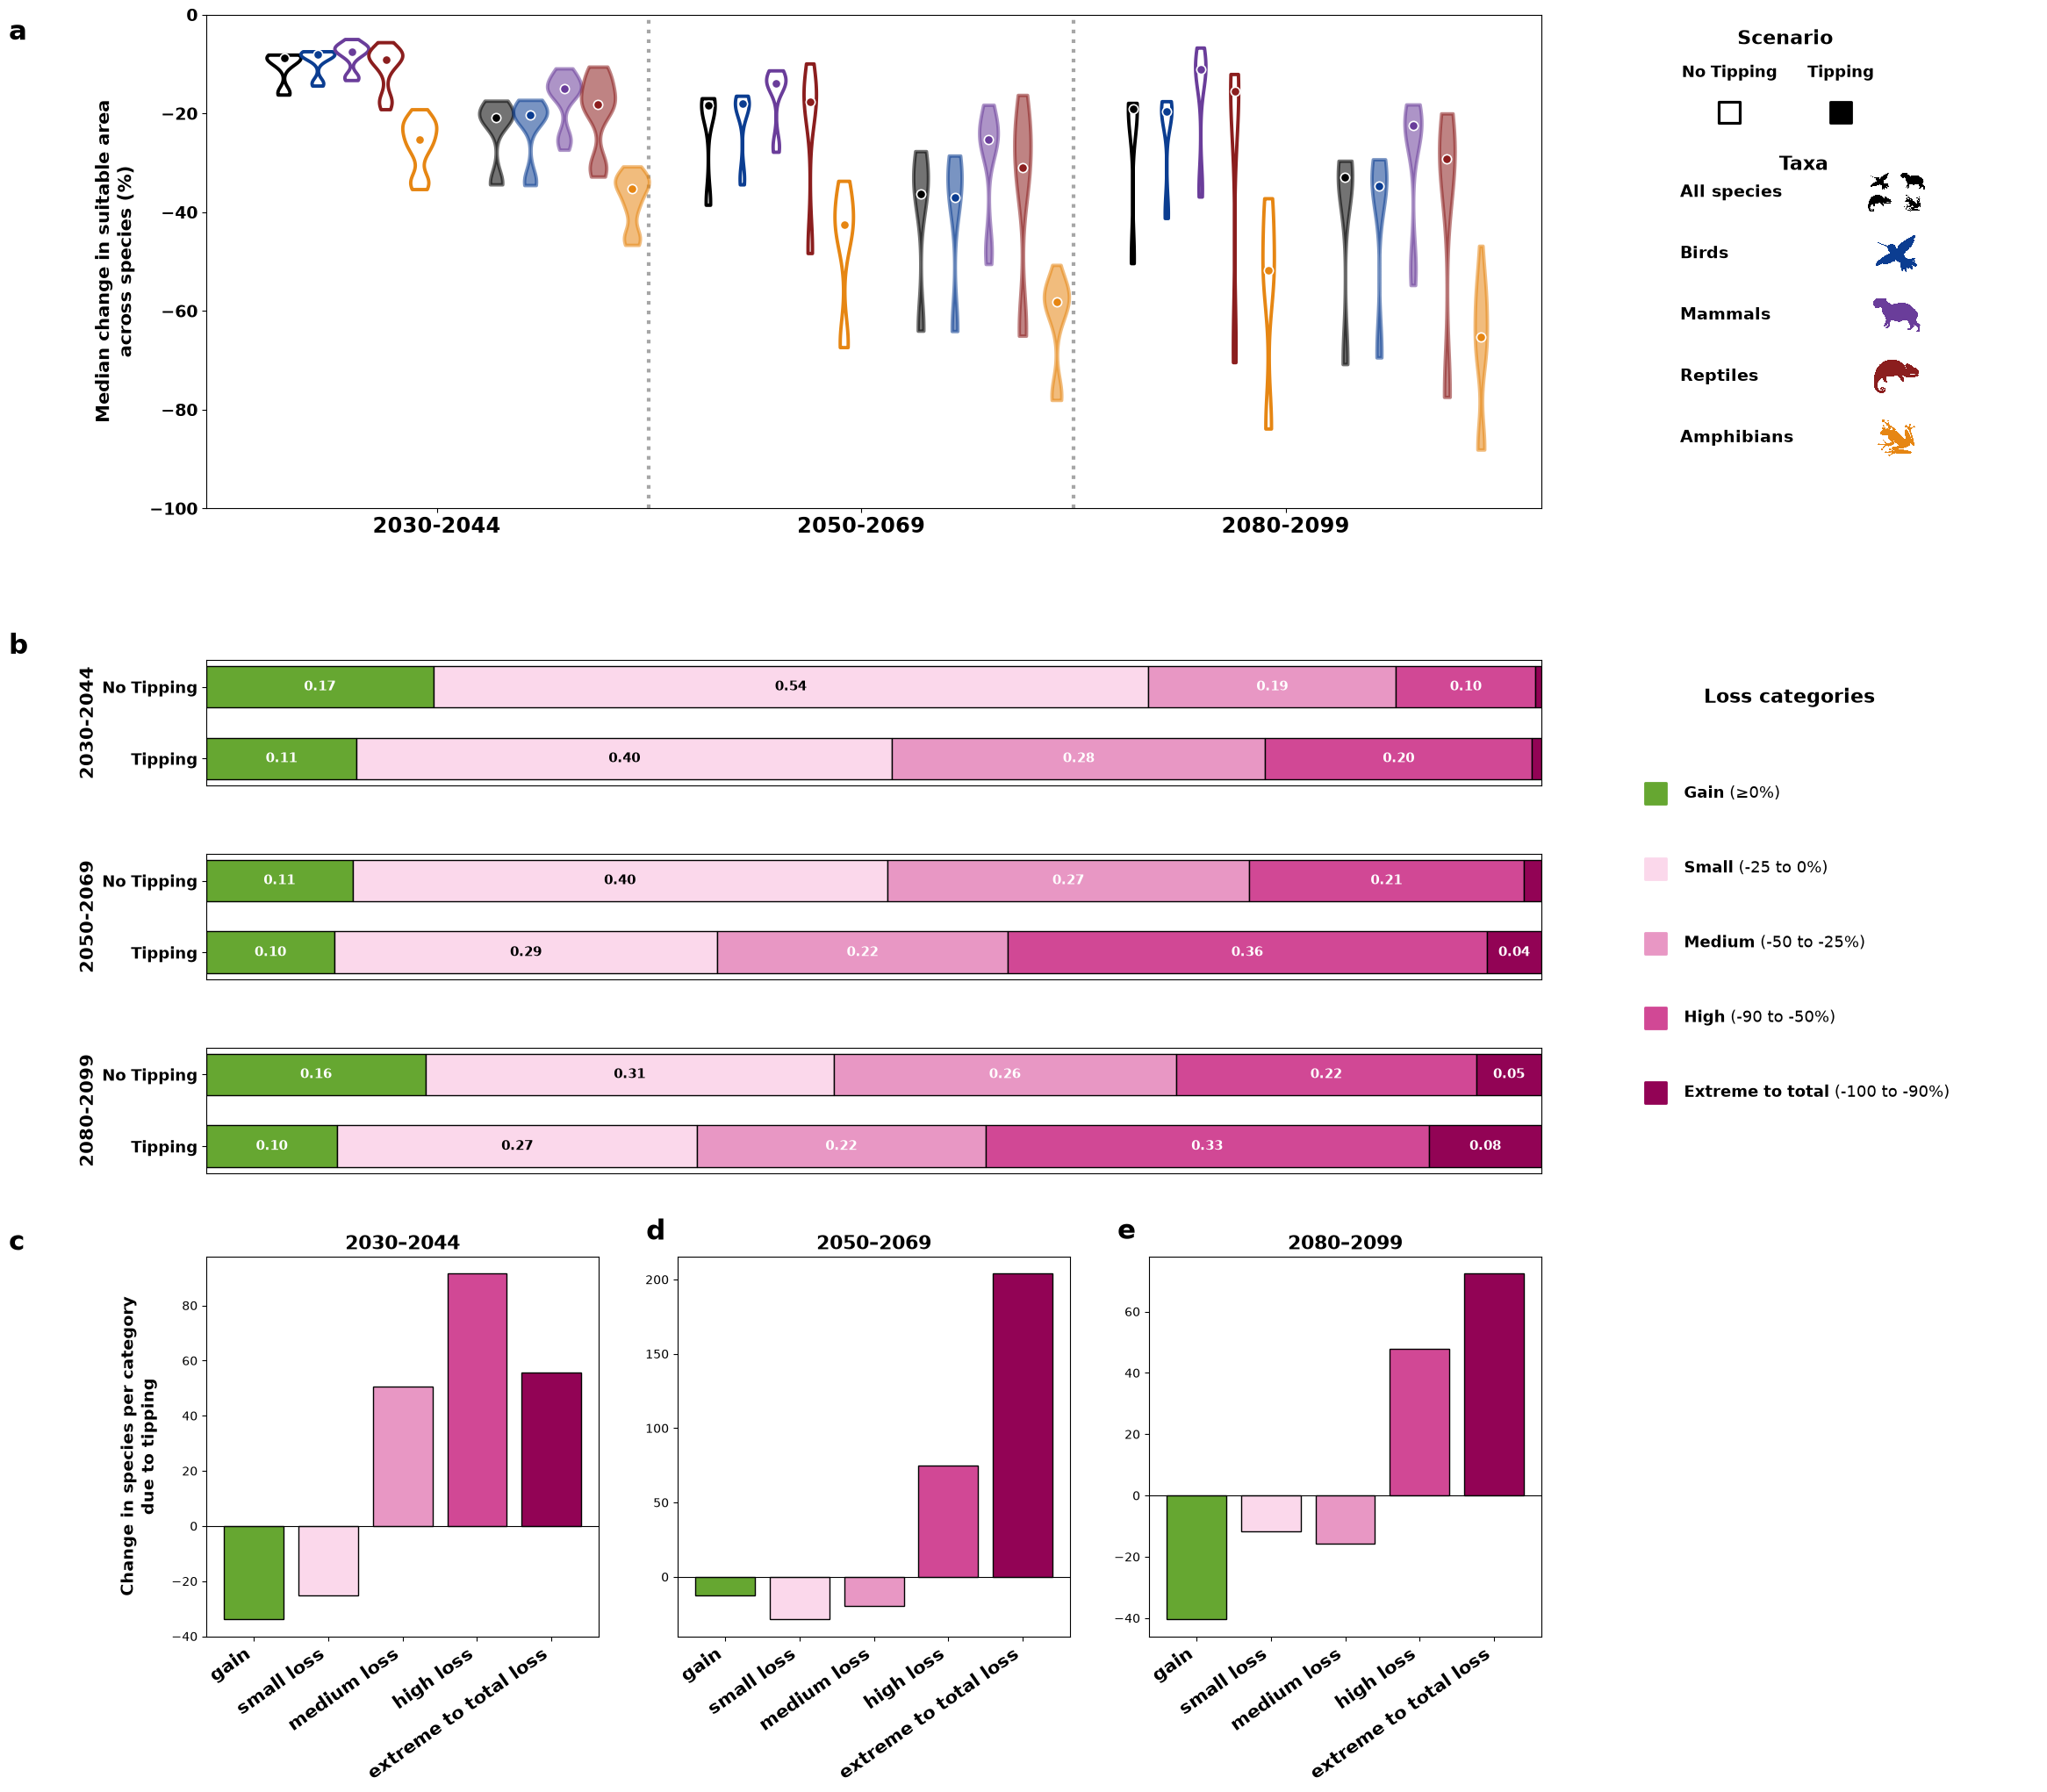

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from matplotlib import colormaps
from matplotlib.collections import PolyCollection
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

tp_pretty = ["2030-2044", "2050-2069", "2080-2099"]
tp_raw = ["2030_2044", "2050_2069", "2080_2099"]
tp_map = dict(zip(tp_raw, tp_pretty))

category_order = [
    "gain",
    "small loss",
    "medium loss",
    "high loss",
    "extreme to total loss"
]

type_order = ["all", "birds", "mammals", "reptiles", "amphibians"]
tip_order = ["notip", "tip"]

plot_df["group"] = plot_df["tip"].astype(str) + "_" + plot_df["type"].astype(str)

group_order = [
    f"{tip}_{taxon}"
    for tip in tip_order
    for taxon in type_order
]

time_order = sorted(plot_df["time_period"].unique())

type_colors = {
    "all": "black",
    "birds": "#0B3D91",       
    "mammals": "#6A3D9A",     
    "reptiles": "#8B1E1E",  
    "amphibians": "#E68613"  
}

fig = plt.figure(figsize=(25, 24))
fig.subplots_adjust(right=0.96)

outer_gs = fig.add_gridspec(
    nrows=5,
    ncols=2,
    width_ratios=[3.6, 1.15],
    height_ratios=[1.30, 0.40, 1.35, 0.22, 1.0],
    wspace=0.08,
    hspace=0.0
)

ax_violin = fig.add_subplot(outer_gs[0, 0])
ax_taxa_legend = fig.add_subplot(outer_gs[0, 1])

ax_loss_legend = fig.add_subplot(outer_gs[2, 1])
gs_bars = outer_gs[2, 0].subgridspec(3, 1, hspace=0.55)
axs_bars = [fig.add_subplot(gs_bars[i]) for i in range(3)]

gs_boxplots = outer_gs[4, 0].subgridspec(1, 3, wspace=0.20)
axs_boxplots = [fig.add_subplot(gs_boxplots[i]) for i in range(3)]
ax_taxa_legend.set_axis_off()

sketch_files = {
    "all": (
        repository_root / "08_figures" / "main_figures" / "figure_3"
        / "species_sketches" / "all_species_figure3.png"
    ),
    "birds": (
        repository_root / "08_figures" / "main_figures" / "figure_3"
        / "species_sketches" / "bird_figure3.png"
    ),
    "mammals": (
        repository_root / "08_figures" / "main_figures" / "figure_3"
        / "species_sketches" / "mammal_figure3.png"
    ),
    "reptiles": (
        repository_root / "08_figures" / "main_figures" / "figure_3"
        / "species_sketches" / "reptile_figure3.png"
    ),
    "amphibians": (
        repository_root / "08_figures" / "main_figures" / "figure_3"
        / "species_sketches" / "amphibian_figure3.png"
    ),
}

taxa = ["all", "birds", "mammals", "reptiles", "amphibians"]
taxa_labels = ["All species", "Birds", "Mammals", "Reptiles", "Amphibians"]
taxa_y = np.arange(len(taxa))[::-1]

no_tipping_x = 0.70
tipping_x = 1.60
taxa_name_x = 0.30
icon_x = 2.05

ax_taxa_legend.set_xlim(-0.25, 3.20)
ax_taxa_legend.set_ylim(-1.05, 7.00)

ax_taxa_legend.text(
    1.15, 6.60, "Scenario",
    ha="center", va="center",
    fontsize=16, fontweight="bold"
)

ax_taxa_legend.text(
    no_tipping_x, 6.05, "No Tipping",
    ha="center", va="center",
    fontsize=13, fontweight="bold"
)

ax_taxa_legend.text(
    tipping_x, 6.05, "Tipping",
    ha="center", va="center",
    fontsize=13, fontweight="bold"
)

ax_taxa_legend.scatter(
    no_tipping_x, 5.40,
    marker="s", s=300,
    facecolor="none", edgecolor="black", linewidth=2.3
)

ax_taxa_legend.scatter(
    tipping_x, 5.40,
    marker="s", s=300,
    facecolor="black", edgecolor="black", linewidth=2
)

ax_taxa_legend.text(
    1.30, 4.55, "Taxa",
    ha="center", va="center",
    fontsize=16, fontweight="bold"
)

def crop_transparent_margin(image):
    if image.ndim != 3 or image.shape[-1] != 4:
        return image

    alpha = image[..., 3]
    rows, columns = np.where(alpha > 0)

    if len(rows) == 0 or len(columns) == 0:
        return image

    return image[
        rows.min():rows.max() + 1,
        columns.min():columns.max() + 1
    ]


for y, taxon, label in zip(taxa_y, taxa, taxa_labels):
    ax_taxa_legend.text(
        taxa_name_x, y + 0.10, label,
        ha="left", va="center",
        fontsize=14, fontweight="bold"
    )

    sketch = crop_transparent_margin(mpimg.imread(sketch_files[taxon]))

    if taxon == "all":
        sketch_zoom = 0.045
    elif taxon == "amphibians":
        sketch_zoom = 0.025
    else:
        sketch_zoom = 0.015

    image = OffsetImage(sketch, zoom=sketch_zoom)

    ax_taxa_legend.add_artist(
        AnnotationBbox(
            image, (icon_x, y + 0.10),
            frameon=False,
            box_alignment=(0.5, 0.5)
        )
    )
sns.violinplot(
    data=plot_df,
    x="time_period",
    y="relative_change_amazon_area_full_dispersal",
    hue="group",
    order=time_order,
    hue_order=group_order,
    dodge=True,
    cut=0,
    inner=None,
    ax=ax_violin
)

def get_type(group):
    return group.split("_", 1)[1]

ax_violin.tick_params(axis="both", labelsize=14)
ax_violin.set_xticklabels([tp_map[time] for time in time_order])

plt.setp(
    ax_violin.get_xticklabels(),
    fontweight="bold",
    fontsize=17
)

plt.setp(
    ax_violin.get_yticklabels(),
    fontweight="bold",
    fontsize=14
)

ax_violin.set_ylim(0, -100)
ax_violin.invert_yaxis()

ax_violin.set_ylabel(
    "Median change in suitable area\nacross species (%)",
    fontweight="bold",
    fontsize=15,
    labelpad=10
)

ax_violin.set_xlabel("")
ax_violin.grid(False)

if ax_violin.legend_ is not None:
    ax_violin.legend_.remove()

violin_bodies = [
    collection
    for collection in ax_violin.collections
    if isinstance(collection, PolyCollection)
]

n_groups = len(group_order)

for i, artist in enumerate(violin_bodies):
    group = group_order[i % n_groups]
    taxon = get_type(group)
    color = type_colors[taxon]

    if group.startswith("notip"):
        artist.set_facecolor("none")
        artist.set_edgecolor(color)
        artist.set_linewidth(2.8)
    else:
        artist.set_facecolor(color)
        artist.set_edgecolor(color)
        artist.set_alpha(0.55)
        artist.set_linewidth(2.8)

for i, artist in enumerate(violin_bodies):
    group = group_order[i % n_groups]

    if group.startswith("tip"):
        for path in artist.get_paths():
            path.vertices[:, 0] += 0.1

median_df = (
    plot_df
    .groupby(["time_period", "tip", "type"])["relative_change_amazon_area_full_dispersal"]
    .median()
    .reset_index()
)

violin_positions = [
    np.mean(collection.get_paths()[0].vertices[:, 0])
    for collection in violin_bodies
]

group_labels = [
    (time, group)
    for time in time_order
    for group in group_order
]

x_map = dict(zip(group_labels, violin_positions))

for _, row in median_df.iterrows():
    group = f"{row['tip']}_{row['type']}"
    x = x_map[(row["time_period"], group)]
    y = row["relative_change_amazon_area_full_dispersal"]
    color = type_colors[row["type"]]

    ax_violin.scatter(
        x, y,
        color=color,
        s=55,
        zorder=15,
        edgecolor="white",
        linewidth=1.2
    )

xticks = ax_violin.get_xticks()

for i in range(len(xticks) - 1):
    midpoint = (xticks[i] + xticks[i + 1]) / 2

    ax_violin.axvline(
        x=midpoint,
        linestyle=":",
        color="gray",
        linewidth=3,
        alpha=0.7,
        zorder=0
    )

ax_loss_legend.set_axis_off()

cmap = colormaps["PiYG"]
category_colors = [cmap(value) for value in [0.85, 0.38, 0.25, 0.15, 0.01]]

loss_items = [
    (r"$\bf{Gain}$ (≥0%)", category_colors[0]),
    (r"$\bf{Small}$ (-25 to 0%)", category_colors[1]),
    (r"$\bf{Medium}$ (-50 to -25%)", category_colors[2]),
    (r"$\bf{High}$ (-90 to -50%)", category_colors[3]),
    (r"$\bf{Extreme\ to\ total}$ (-100 to -90%)", category_colors[4]),
]

ax_loss_legend.set_xlim(-0.20, 4.25)
ax_loss_legend.set_ylim(-0.25, 4.55)

ax_loss_legend.text(
    1.65, 4.20, "Loss categories",
    ha="center", va="center",
    fontsize=16, fontweight="bold"
)

for y, (label, color) in zip([3.20, 2.50, 1.80, 1.10, 0.40], loss_items):
    ax_loss_legend.scatter(
        0.25, y + 0.10,
        marker="s", s=300,
        facecolor=color,
        edgecolor=color,
        linewidth=2
    )

    ax_loss_legend.text(
        0.55, y + 0.10, label,
        ha="left", va="center",
        fontsize=13
    )
def classify_loss(x):
    if -100 <= x < -90:
        return "extreme to total loss"
    if -90 <= x < -50:
        return "high loss"
    if -50 <= x < -25:
        return "medium loss"
    if -25 <= x < 0:
        return "small loss"
    if x >= 0:
        return "gain"
    return "undefined"

mean_area = (
    area_csv
    .groupby(["species_name", "ssp", "tip", "deforestation", "time_period"])
    [f"relative_change_amazon_area_{dispersal_scenario}"]
    .mean()
    .reset_index()
)

scenarios = [
    ("no tip", "notip", "no_deforestation"),
    ("tip + no defor", "tip", "no_deforestation"),
    ("tip + defor", "tip", "deforestation")
]

rows = []

for label, tip, defor in scenarios:
    for time in tp_raw:
        df_s = mean_area[
            (mean_area["ssp"] == ssp)
            & (mean_area["tip"] == tip)
            & (mean_area["deforestation"] == defor)
            & (mean_area["time_period"] == time)
        ].copy()

        df_s["loss_category"] = df_s[
            f"relative_change_amazon_area_{dispersal_scenario}"
        ].apply(classify_loss)

        total = len(df_s)

        ratios = (
            df_s["loss_category"]
            .value_counts()
            .reindex(category_order, fill_value=0)
            / total
        )

        row = {"scenario": label, "time_period": time}
        row.update(ratios.to_dict())
        rows.append(row)

ratio_df = pd.DataFrame(rows)

baseline = ratio_df[ratio_df["scenario"] == "no tip"]
tip_defor = ratio_df[ratio_df["scenario"] == "tip + defor"]

delta_ratio_df = baseline.merge(
    tip_defor,
    on="time_period",
    suffixes=("_b", "_t")
)

for category in category_order:
    delta_ratio_df[category] = (
        (
            delta_ratio_df[f"{category}_t"]
            - delta_ratio_df[f"{category}_b"]
        )
        / delta_ratio_df[f"{category}_b"]
    ) * 100

tp_pretty_map = dict(zip(tp_raw, tp_pretty))

for ax, time in zip(axs_bars, tp_raw):
    df_tp = ratio_df[
        (ratio_df["scenario"].isin(["no tip", "tip + defor"]))
        & (ratio_df["time_period"] == time)
    ]

    data = np.array([
        df_tp[df_tp["scenario"] == scenario][category_order].values[0]
        for scenario in ["no tip", "tip + defor"]
    ])

    data_cum = data.cumsum(axis=1)

    ax.invert_yaxis()
    ax.get_xaxis().set_visible(False)

    y_positions = [0, 0.6]

    ax.set_yticks(y_positions)
    ax.set_yticklabels(
        ["No Tipping", "Tipping"],
        fontsize=13,
        fontweight="bold"
    )

    for i, (category, color) in enumerate(
        zip(category_order, category_colors)
    ):
        widths = data[:, i]
        starts = data_cum[:, i] - widths

        rects = ax.barh(
            y_positions,
            widths,
            left=starts,
            height=0.35,
            color=color,
            edgecolor="black"
        )

        r, g, b, _ = color
        text_color = "white" if r * g * b < 0.5 else "black"

        ax.bar_label(
            rects,
            labels=[
                f"{width:.2f}" if width >= 0.04 else ""
                for width in widths
            ],
            label_type="center",
            fontsize=11,
            fontweight="bold",
            color=text_color
        )

    ax.set_ylabel(
        tp_pretty_map[time],
        fontweight="bold",
        fontsize=15
    )

    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.set_xlabel("")

letters = ["c", "d", "e"]

for ax, time, letter in zip(axs_boxplots, tp_raw, letters):
    row = delta_ratio_df[delta_ratio_df["time_period"] == time]
    values = row[category_order].iloc[0]

    ax.bar(category_order, values, color=category_colors, edgecolor="black")
    ax.axhline(0, color="black", lw=0.8)

    ax.set_title(time.replace("_", "–"), fontweight="bold", fontsize=16)

    ax.set_xticklabels(
        category_order,
        rotation=35,
        ha="right",
        fontweight="bold",
        fontsize=15
    )

    if letter == "c":
        ax.set_ylabel(
            "Change in species per category\ndue to tipping",
            fontweight="bold",
            fontsize=14,
            labelpad=10
        )
    else:
        ax.set_ylabel("")

    ax.grid(False)

    if letter != "c":
        ax.text(
            -0.08, 1.10, letter,
            transform=ax.transAxes,
            fontsize=22,
            fontweight="bold",
            va="top"
        )

label_x = 0.035

fig.text(
    label_x,
    ax_taxa_legend.get_position().y1 - 0.015,
    "a",
    fontsize=22,
    fontweight="bold",
    ha="left",
    va="bottom"
)

fig.text(
    label_x,
    ax_loss_legend.get_position().y1,
    "b",
    fontsize=22,
    fontweight="bold",
    ha="left",
    va="bottom"
)

fig.text(
    label_x,
    axs_boxplots[0].get_position().y1,
    "c",
    fontsize=22,
    fontweight="bold",
    ha="left",
    va="bottom"
)

plt.savefig(
    save_dir / "final_figure_3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()